In [28]:
# ============================================
# Credit Risk Scorer — Project Notebook
# ============================================

import pandas as pd                          # for loading and working with data tables
import numpy as np                           # for numerical calculations
import matplotlib.pyplot as plt              # for drawing charts
import seaborn as sns                        # for beautiful statistical charts

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

from xgboost import XGBClassifier            # powerful tree-based model
from imblearn.over_sampling import SMOTE     # fixes class imbalance
import shap                                  # explains model predictions
import joblib                                # saves trained model to disk

import warnings
warnings.filterwarnings('ignore')            # hides non-critical warning messages
pd.set_option('display.max_columns', None)  # shows all columns, nothing hidden

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [29]:
# ============================================
# Phase 1 — Step 1: Load the Dataset
# ============================================

df = pd.read_csv('../data/credit_risk.csv')  # loads CSV from data folder into df

print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)                    # prints (rows, columns)

✅ Dataset loaded successfully!
Shape: (150000, 12)


In [30]:
# ============================================
# Phase 1 — Step 2: View First 5 Rows
# ============================================

df.head()    # shows first 5 rows of the dataset as a table

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [31]:
# ============================================
# Phase 1 — Step 3: Column Names and Data Types
# ============================================

print("Column Names and Data Types:")
print("="*45)                # prints a divider line for readability
print(df.dtypes)             # shows each column name and its data type

Column Names and Data Types:
Unnamed: 0                                int64
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object


In [32]:
# ============================================
# Phase 1 — Step 4: Check Missing Values
# ============================================

missing_count = df.isnull().sum()              # counts missing values per column
missing_percent = df.isnull().mean() * 100     # calculates missing % per column

missing_df = pd.DataFrame({                    # combines both into one neat table
    'Missing Count': missing_count,
    'Missing %': missing_percent.round(2)      # rounds to 2 decimal places
})

print("Missing Value Report:")
print("="*45)
print(missing_df[missing_df['Missing Count'] > 0])  # shows only columns WITH missing values


Missing Value Report:
                    Missing Count  Missing %
MonthlyIncome               29731      19.82
NumberOfDependents           3924       2.62


In [33]:
# ============================================
# Phase 1 — Step 5: Check Target Column Balance
# ============================================

target_count = df['SeriousDlqin2yrs'].value_counts()        # counts 0s and 1s
target_percent = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100  # as %

target_df = pd.DataFrame({                                   # combines into one table
    'Count': target_count,
    'Percentage': target_percent.round(2)
})

print("Target Column Balance:")
print("="*45)
print(target_df)
print()
print("Total defaulters (1):", target_count[1])              # prints defaulter count
print("Total non-defaulters (0):", target_count[0])          # prints non-defaulter count

Target Column Balance:
                   Count  Percentage
SeriousDlqin2yrs                    
0                 139974       93.32
1                  10026        6.68

Total defaulters (1): 10026
Total non-defaulters (0): 139974


In [34]:
# ============================================
# Phase 1 — Step 6: Basic Statistics
# ============================================

print("Basic Statistics for All Columns:")
print("="*45)
df.describe().T        # .T means transpose — flips rows and columns for easier reading

Basic Statistics for All Columns:


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,150000.0,75000.500000,43301.414527,1.0,37500.750000,75000.500000,112500.250000,150000.0
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0


In [35]:
# ============================================
# Phase 2 — Step 1: Drop Unnamed Column
# ============================================

df = df.drop(columns=['Unnamed: 0'])   # removes the serial number column permanently

print("✅ Unnamed column dropped")
print("New shape:", df.shape)          # should now show 11 columns instead of 12

✅ Unnamed column dropped
New shape: (150000, 11)


In [36]:
# ============================================
# Phase 2 — Step 2: Fix age = 0
# ============================================

print("Rows where age = 0:", (df['age'] == 0).sum())   # counts how many age=0 rows exist

df = df[df['age'] > 0]                                 # keeps only rows where age is above 0

print("✅ Age = 0 rows removed")
print("New shape:", df.shape)                          # confirms how many rows remain

Rows where age = 0: 1
✅ Age = 0 rows removed
New shape: (149999, 11)


In [37]:
# ============================================
# Phase 2 — Step 3: Fix max = 98 in Late Columns
# ============================================

# first let's see how many rows have 98 in each column
col1 = 'NumberOfTime30-59DaysPastDueNotWorse'
col2 = 'NumberOfTimes90DaysLate'
col3 = 'NumberOfTime60-89DaysPastDueNotWorse'

print("Rows with 98 in 30-59 days column:", (df[col1] == 98).sum())   # count bad rows
print("Rows with 98 in 90 days column:", (df[col2] == 98).sum())      # count bad rows
print("Rows with 98 in 60-89 days column:", (df[col3] == 98).sum())   # count bad rows

# now remove all rows where ANY of these columns has value 98
df = df[(df[col1] != 98) & (df[col2] != 98) & (df[col3] != 98)]      # keeps only clean rows

print()
print("✅ Rows with 98 removed")
print("New shape:", df.shape)                                          # confirms rows remaining

Rows with 98 in 30-59 days column: 264
Rows with 98 in 90 days column: 264
Rows with 98 in 60-89 days column: 264

✅ Rows with 98 removed
New shape: (149735, 11)


In [38]:
# ============================================
# Phase 2 — Step 4: Fill Missing Values
# ============================================

# check missing values BEFORE filling
print("Missing values BEFORE filling:")
print("MonthlyIncome:", df['MonthlyIncome'].isnull().sum())          # count missing income
print("NumberOfDependents:", df['NumberOfDependents'].isnull().sum()) # count missing dependents
print()

# calculate medians
income_median = df['MonthlyIncome'].median()                          # finds middle income value
dependents_median = df['NumberOfDependents'].median()                 # finds middle dependents value

print("Median MonthlyIncome:", income_median)                         # shows what we will fill with
print("Median NumberOfDependents:", dependents_median)                # shows what we will fill with
print()

# fill missing values with median
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(income_median)           # fills income gaps
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(dependents_median) # fills dependents gaps

# check missing values AFTER filling
print("Missing values AFTER filling:")
print("MonthlyIncome:", df['MonthlyIncome'].isnull().sum())           # should now be 0
print("NumberOfDependents:", df['NumberOfDependents'].isnull().sum()) # should now be 0
print()
print("✅ Missing values filled successfully")

Missing values BEFORE filling:
MonthlyIncome: 29611
NumberOfDependents: 3893

Median MonthlyIncome: 5400.0
Median NumberOfDependents: 0.0

Missing values AFTER filling:
MonthlyIncome: 0
NumberOfDependents: 0

✅ Missing values filled successfully


In [39]:
# ============================================
# Phase 2 — Step 5: Cap Extreme Outliers
# ============================================

# --- RevolvingUtilization ---
revolving_cap = df['RevolvingUtilizationOfUnsecuredLines'].quantile(0.99)  # finds 99th percentile
print("RevolvingUtilization 99th percentile:", revolving_cap)               # shows cap value

df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=revolving_cap)  # caps values above limit

# --- DebtRatio ---
debtratio_cap = df['DebtRatio'].quantile(0.99)                             # finds 99th percentile
print("DebtRatio 99th percentile:", debtratio_cap)                          # shows cap value

df['DebtRatio'] = df['DebtRatio'].clip(upper=debtratio_cap)                # caps values above limit

# --- MonthlyIncome ---
income_cap = df['MonthlyIncome'].quantile(0.99)                            # finds 99th percentile
print("MonthlyIncome 99th percentile:", income_cap)                         # shows cap value

df['MonthlyIncome'] = df['MonthlyIncome'].clip(upper=income_cap)           # caps values above limit

print()
print("✅ Outliers capped successfully")
print("New max RevolvingUtilization:", df['RevolvingUtilizationOfUnsecuredLines'].max())  # confirms new max
print("New max DebtRatio:", df['DebtRatio'].max())                          # confirms new max
print("New max MonthlyIncome:", df['MonthlyIncome'].max())                  # confirms new max

RevolvingUtilization 99th percentile: 1.0933365239000006
DebtRatio 99th percentile: 4983.0
MonthlyIncome 99th percentile: 23011.22000000006

✅ Outliers capped successfully
New max RevolvingUtilization: 1.0933365239000006
New max DebtRatio: 4983.0
New max MonthlyIncome: 23011.22000000006


In [40]:
# ============================================
# Phase 2 — Step 6: Final Verification
# ============================================

print("=" * 50)
print("PHASE 2 — FINAL DATA VERIFICATION REPORT")
print("=" * 50)

# 1. Shape
print("\n📐 Dataset Shape:")
print(df.shape)                                      # rows and columns remaining

# 2. Missing values
print("\n🔍 Missing Values Per Column:")
print(df.isnull().sum())                             # should show all zeros

# 3. Data types
print("\n📋 Data Types:")
print(df.dtypes)                                     # confirms all numeric

# 4. Key column maximums
print("\n📊 Key Column Maximums After Cleaning:")
print("Max age:", df['age'].max())                   # confirms no age = 0
print("Max RevolvingUtilization:", 
      df['RevolvingUtilizationOfUnsecuredLines'].max())   # confirms capped
print("Max DebtRatio:", df['DebtRatio'].max())       # confirms capped
print("Max MonthlyIncome:", df['MonthlyIncome'].max()) # confirms capped
print("Max 30-59 days late:", 
      df['NumberOfTime30-59DaysPastDueNotWorse'].max())   # confirms no 98
print("Max 90 days late:", 
      df['NumberOfTimes90DaysLate'].max())            # confirms no 98
print("Max 60-89 days late:", 
      df['NumberOfTime60-89DaysPastDueNotWorse'].max())   # confirms no 98

# 5. Target column still intact
print("\n🎯 Target Column Balance:")
print(df['SeriousDlqin2yrs'].value_counts())         # confirms 0s and 1s still present

print("\n" + "=" * 50)
print("✅ DATA CLEANING COMPLETE — READY FOR EDA")
print("=" * 50)

PHASE 2 — FINAL DATA VERIFICATION REPORT

📐 Dataset Shape:
(149735, 11)

🔍 Missing Values Per Column:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

📋 Data Types:
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrL

Task was destroyed but it is pending!
task: <Task pending name='Task-227' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\LGS\Desktop\DS-Month-2_3\credit-risk-scorer\venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-228' coro=<Kernel.shell_main() running at C:\Users\LGS\Desktop\DS-Month-2_3\credit-risk-scorer\venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\LGS\Desktop\DS-Month-2_3\credit-risk-scorer\venv\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-228' coro=<Kernel.shell_main() running at C:\Users\LGS\Desktop\DS-Month-2_3\credit-risk-scorer\venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


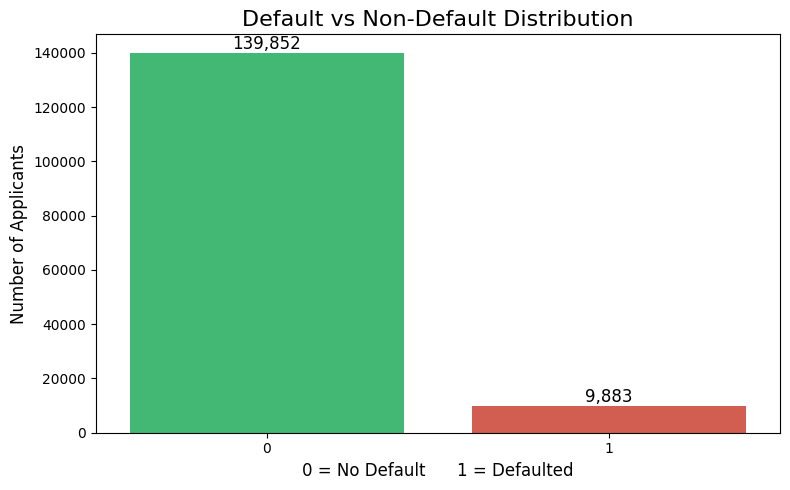

In [41]:
# ============================================
# Phase 3 — Step 1: Target Column Countplot
# ============================================

plt.figure(figsize=(8, 5))                        # sets chart size

sns.countplot(x='SeriousDlqin2yrs',               # column to count
              data=df,                             # dataset to use
              palette=['#2ecc71', '#e74c3c'])      # green for 0, red for 1

plt.title('Default vs Non-Default Distribution',   # chart title
          fontsize=16)
plt.xlabel('0 = No Default      1 = Defaulted',   # x axis label
           fontsize=12)
plt.ylabel('Number of Applicants',                 # y axis label
           fontsize=12)

# add count labels on top of each bar
for p in plt.gca().patches:                        # loops through each bar
    plt.gca().annotate(f'{int(p.get_height()):,}', # formats number with comma
                      (p.get_x() + p.get_width() / 2, p.get_height()),
                      ha='center', va='bottom',    # centers the label
                      fontsize=12)

plt.tight_layout()                                 # prevents cutting off labels
plt.show()                                         # displays the chart

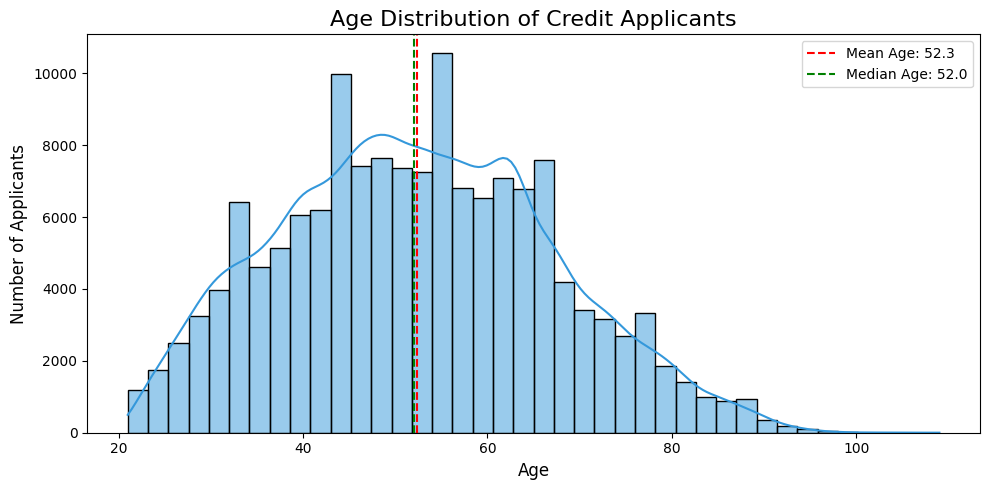

In [42]:
# ============================================
# Phase 3 — Step 2: Age Distribution Histogram
# ============================================

plt.figure(figsize=(10, 5))                          # sets chart size

sns.histplot(data=df,                                # dataset to use
             x='age',                               # column to plot
             bins=40,                               # divides age range into 40 groups
             kde=True,                              # adds smooth curve on top
             color='#3498db')                       # blue color

plt.title('Age Distribution of Credit Applicants',  # chart title
          fontsize=16)
plt.xlabel('Age',                                   # x axis label
           fontsize=12)
plt.ylabel('Number of Applicants',                  # y axis label
           fontsize=12)

plt.axvline(df['age'].mean(),                       # draws vertical line at mean age
            color='red',
            linestyle='--',
            label=f"Mean Age: {df['age'].mean():.1f}")  # labels the line

plt.axvline(df['age'].median(),                     # draws vertical line at median age
            color='green',
            linestyle='--',
            label=f"Median Age: {df['age'].median():.1f}")  # labels the line

plt.legend()                                        # shows the line labels
plt.tight_layout()                                  # prevents cutting off labels
plt.show()                                          # displays the chart

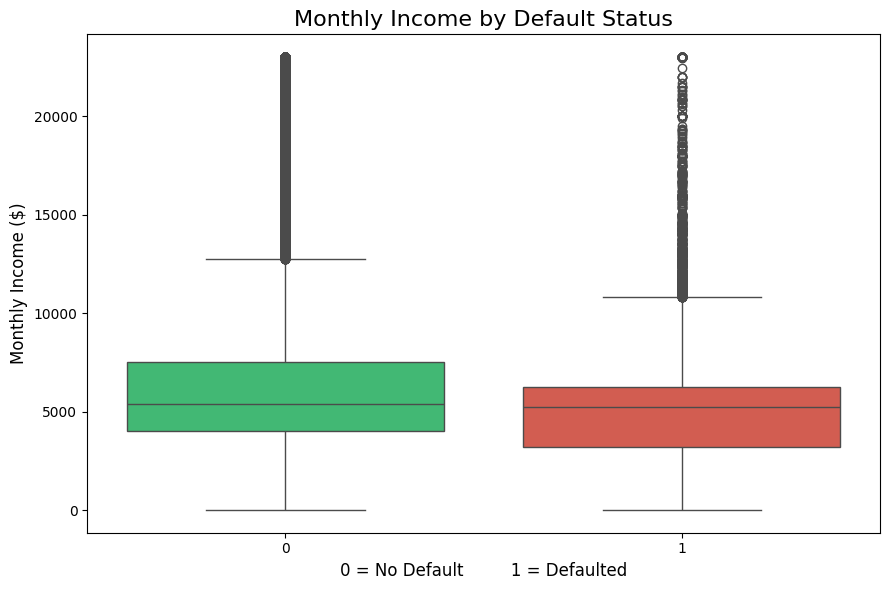

In [43]:
# ============================================
# Phase 3 — Step 3: Boxplot — Income vs Default
# ============================================

plt.figure(figsize=(9, 6))                            # sets chart size

sns.boxplot(x='SeriousDlqin2yrs',                     # x axis — default status
            y='MonthlyIncome',                        # y axis — income
            data=df,                                  # dataset
            palette=['#2ecc71', '#e74c3c'])           # green for 0, red for 1

plt.title('Monthly Income by Default Status',         # chart title
          fontsize=16)
plt.xlabel('0 = No Default         1 = Defaulted',   # x axis label
           fontsize=12)
plt.ylabel('Monthly Income ($)',                      # y axis label
           fontsize=12)

plt.tight_layout()                                    # prevents cutting off labels
plt.show()                                            # displays the chart

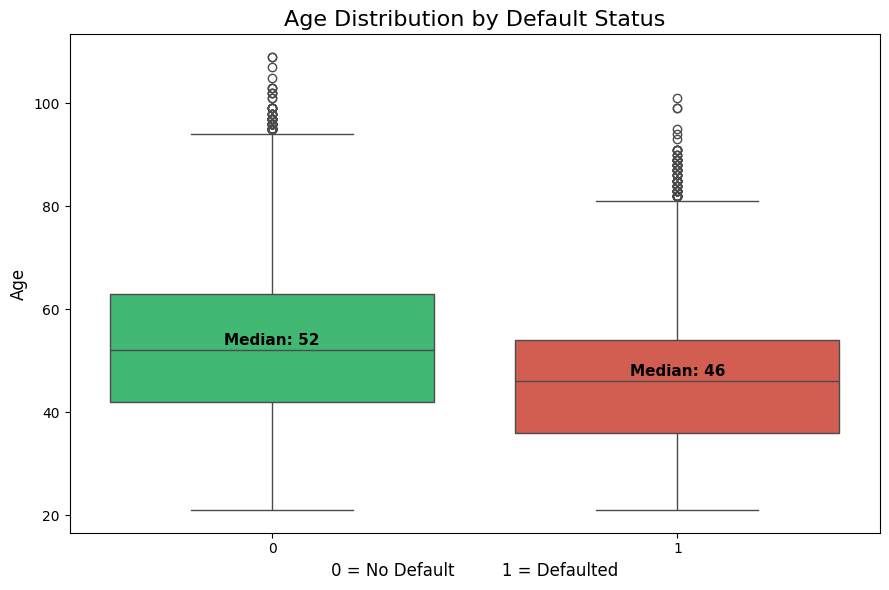

In [44]:
# ============================================
# Phase 3 — Step 4: Boxplot — Age vs Default
# ============================================

plt.figure(figsize=(9, 6))                            # sets chart size

sns.boxplot(x='SeriousDlqin2yrs',                     # x axis — default status
            y='age',                                  # y axis — age
            data=df,                                  # dataset
            palette=['#2ecc71', '#e74c3c'])           # green for 0, red for 1

plt.title('Age Distribution by Default Status',       # chart title
          fontsize=16)
plt.xlabel('0 = No Default         1 = Defaulted',   # x axis label
           fontsize=12)
plt.ylabel('Age',                                     # y axis label
           fontsize=12)

# add median age labels on each box
medians = df.groupby('SeriousDlqin2yrs')['age'].median()  # calculates median age per group
for i, median in enumerate(medians):                       # loops through both groups
    plt.text(i, median + 1,                               # positions text just above median line
             f'Median: {median:.0f}',                     # formats median as whole number
             ha='center',                                 # centers the text
             fontsize=11,
             color='black',
             fontweight='bold')

plt.tight_layout()                                    # prevents cutting off labels
plt.show()                                            # displays the chart

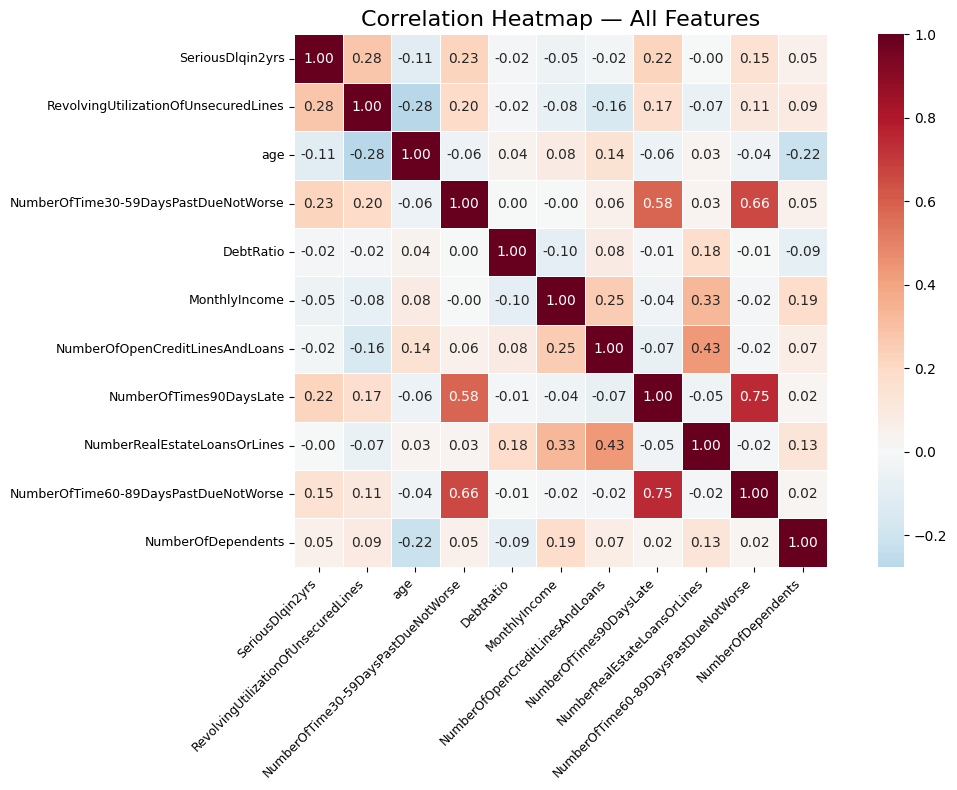

In [45]:
# ============================================
# Phase 3 — Step 5: Correlation Heatmap
# ============================================

plt.figure(figsize=(12, 8))                           # sets chart size — wide for all columns

correlation_matrix = df.corr()                        # calculates correlation between all columns

sns.heatmap(correlation_matrix,                       # data to plot
            annot=True,                               # shows numbers inside each cell
            fmt='.2f',                                # rounds numbers to 2 decimal places
            cmap='RdBu_r',                            # red for positive, blue for negative
            center=0,                                 # white colour at zero
            square=True,                              # makes each cell square shaped
            linewidths=0.5)                           # adds thin lines between cells

plt.title('Correlation Heatmap — All Features',       # chart title
          fontsize=16)
plt.xticks(rotation=45,                               # rotates x axis labels 45 degrees
           ha='right',                                # aligns rotated labels to right
           fontsize=9)
plt.yticks(fontsize=9)                                # sets y axis label size
plt.tight_layout()                                    # prevents cutting off labels
plt.show()                                            # displays the chart

Average Late Payments by Default Status:
                  NumberOfTime30-59DaysPastDueNotWorse  \
SeriousDlqin2yrs                                         
0                                                0.196   
1                                                1.005   

                  NumberOfTimes90DaysLate  \
SeriousDlqin2yrs                            
0                                   0.051   
1                                   0.704   

                  NumberOfTime60-89DaysPastDueNotWorse  
SeriousDlqin2yrs                                        
0                                                0.042  
1                                                0.437  



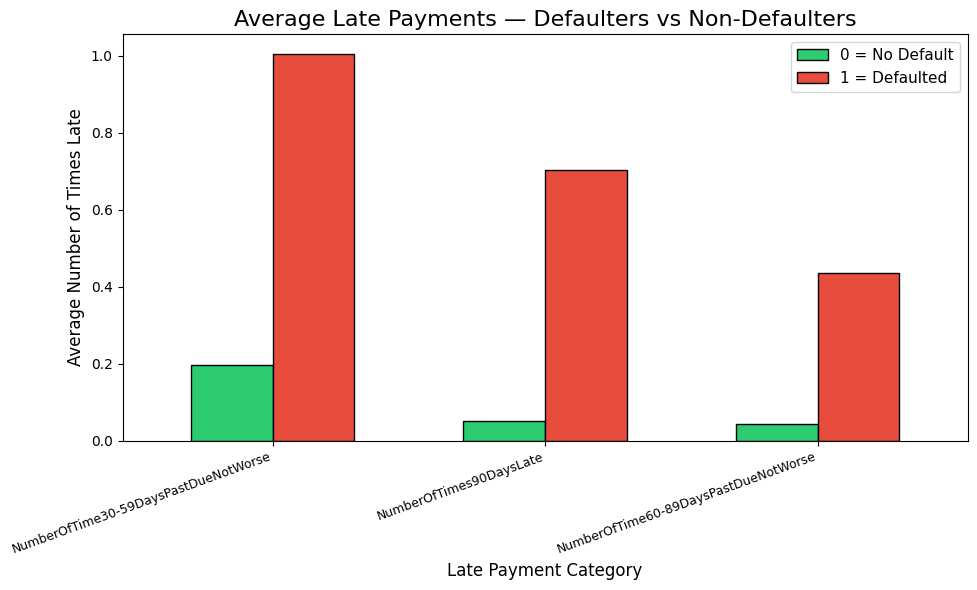

In [46]:
# ============================================
# Phase 3 — Step 6: Average Late Payments
#            by Default Status
# ============================================

# calculate average late payments for each group
late_cols = ['NumberOfTime30-59DaysPastDueNotWorse',  # list of late payment columns
             'NumberOfTimes90DaysLate',
             'NumberOfTime60-89DaysPastDueNotWorse']

late_avg = df.groupby('SeriousDlqin2yrs')[late_cols].mean()  # calculates mean per group

print("Average Late Payments by Default Status:")
print("="*55)
print(late_avg.round(3))                              # shows averages rounded to 3 decimals
print()

# draw the bar chart
late_avg.T.plot(kind='bar',                           # .T flips rows and columns
                figsize=(10, 6),                      # sets chart size
                color=['#2ecc71', '#e74c3c'],         # green for 0, red for 1
                edgecolor='black',                    # adds black border to bars
                width=0.6)                            # sets bar width

plt.title('Average Late Payments — Defaulters vs Non-Defaulters',
          fontsize=16)
plt.xlabel('Late Payment Category',                   # x axis label
           fontsize=12)
plt.ylabel('Average Number of Times Late',            # y axis label
           fontsize=12)
plt.xticks(rotation=20,                               # slight rotation for readability
           ha='right',
           fontsize=9)
plt.legend(['0 = No Default', '1 = Defaulted'],       # explains the colours
           fontsize=11)
plt.tight_layout()                                    # prevents cutting off labels
plt.show()                                            # displays the chart

In [47]:
# ============================================
# Phase 4 — Step 1: Create TotalLatePayments
# ============================================

df['TotalLatePayments'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] +   # adds 30-59 day lates
    df['NumberOfTimes90DaysLate'] +                # adds 90 day lates
    df['NumberOfTime60-89DaysPastDueNotWorse']     # adds 60-89 day lates
)

print("✅ TotalLatePayments column created")
print()
print("Average TotalLatePayments by Default Status:")
print("="*45)
print(df.groupby('SeriousDlqin2yrs')['TotalLatePayments'].mean().round(3))  # confirms new feature works
print()
print("Sample values:")
print(df['TotalLatePayments'].describe().round(2))  # shows statistics of new column

✅ TotalLatePayments column created

Average TotalLatePayments by Default Status:
SeriousDlqin2yrs
0    0.288
1    2.145
Name: TotalLatePayments, dtype: float64

Sample values:
count    149735.00
mean          0.41
std           1.99
min           0.00
25%           0.00
50%           0.00
75%           0.00
max         288.00
Name: TotalLatePayments, dtype: float64


In [48]:
# ============================================
# Phase 4 — Step 2: Create IncomePerDependent
# ============================================

df['IncomePerDependent'] = (
    df['MonthlyIncome'] /                          # monthly income
    (df['NumberOfDependents'] + 1)                 # divided by dependents + 1
)

print("✅ IncomePerDependent column created")
print()
print("Average IncomePerDependent by Default Status:")
print("="*45)
print(df.groupby('SeriousDlqin2yrs')['IncomePerDependent'].mean().round(2))  # confirms feature works
print()
print("Sample values:")
print(df['IncomePerDependent'].describe().round(2))  # shows statistics of new column

✅ IncomePerDependent column created

Average IncomePerDependent by Default Status:
SeriousDlqin2yrs
0    4476.21
1    3689.51
Name: IncomePerDependent, dtype: float64

Sample values:
count    149735.00
mean       4424.28
std        3181.77
min           0.00
25%        2155.00
50%        4000.00
75%        5400.00
max       23011.22
Name: IncomePerDependent, dtype: float64


In [49]:
# ============================================
# Phase 4 — Step 3: Create AgeGroup
# ============================================

df['AgeGroup'] = pd.cut(
    df['age'],                                     # column to bin
    bins=[0, 35, 55, 120],                         # boundaries: 0-35, 35-55, 55-120
    labels=['Young', 'Middle', 'Senior'],           # names for each group
    right=False                                    # 35 goes into Middle not Young
)

print("✅ AgeGroup column created")
print()
print("AgeGroup Distribution:")
print("="*45)
print(df['AgeGroup'].value_counts())               # shows how many in each group
print()
print("Default Rate by AgeGroup:")
print("="*45)
print(df.groupby('AgeGroup')['SeriousDlqin2yrs'].mean().round(4) * 100)  # default % per group

✅ AgeGroup column created

AgeGroup Distribution:
AgeGroup
Senior    65394
Middle    65270
Young     19071
Name: count, dtype: int64

Default Rate by AgeGroup:
AgeGroup
Young     10.87
Middle     8.26
Senior     3.70
Name: SeriousDlqin2yrs, dtype: float64


In [50]:
# ============================================
# Phase 4 — Final Check: All Features Ready
# ============================================

print("=" * 55)
print("PHASE 4 — FINAL FEATURE CHECK REPORT")
print("=" * 55)

# 1. Dataset shape
print("\n📐 Final Dataset Shape:")
print(df.shape)                                       # rows and columns

# 2. All column names
print("\n📋 All Columns:")
for col in df.columns:                                # loops through every column
    print(f"   → {col}")                              # prints each column name

# 3. New feature columns specifically
print("\n✨ New Features Created in Phase 4:")
new_features = ['TotalLatePayments',
                'IncomePerDependent',
                'AgeGroup']
for feat in new_features:                             # loops through new features
    print(f"   → {feat}: {df[feat].dtype}")           # prints name and data type

# 4. Missing values check
print("\n🔍 Missing Values Check:")
missing = df.isnull().sum()                           # counts missing per column
missing_cols = missing[missing > 0]                   # filters only columns with missing
if len(missing_cols) == 0:                            # if no missing values found
    print("   ✅ Zero missing values across all columns")
else:
    print(missing_cols)                               # prints columns that have missing

# 5. Final column count
print("\n📊 Column Summary:")
print(f"   Original columns  : 11")                  # after Phase 2 cleaning
print(f"   New columns added : 3")                   # from Phase 4
print(f"   Total columns now : {df.shape[1]}")        # current total

print("\n" + "=" * 55)
print("✅ FEATURE ENGINEERING COMPLETE — READY FOR MODELLING")
print("=" * 55)

PHASE 4 — FINAL FEATURE CHECK REPORT

📐 Final Dataset Shape:
(149735, 14)

📋 All Columns:
   → SeriousDlqin2yrs
   → RevolvingUtilizationOfUnsecuredLines
   → age
   → NumberOfTime30-59DaysPastDueNotWorse
   → DebtRatio
   → MonthlyIncome
   → NumberOfOpenCreditLinesAndLoans
   → NumberOfTimes90DaysLate
   → NumberRealEstateLoansOrLines
   → NumberOfTime60-89DaysPastDueNotWorse
   → NumberOfDependents
   → TotalLatePayments
   → IncomePerDependent
   → AgeGroup

✨ New Features Created in Phase 4:
   → TotalLatePayments: int64
   → IncomePerDependent: float64
   → AgeGroup: category

🔍 Missing Values Check:
   ✅ Zero missing values across all columns

📊 Column Summary:
   Original columns  : 11
   New columns added : 3
   Total columns now : 14

✅ FEATURE ENGINEERING COMPLETE — READY FOR MODELLING


In [51]:
# ============================================
# Phase 5 — Step 1: Prepare X and y
# ============================================

# drop target column and AgeGroup (text) from features
X = df.drop(columns=['SeriousDlqin2yrs', 'AgeGroup'])  # all columns except target and text

# target column only
y = df['SeriousDlqin2yrs']                              # what we want to predict

print("✅ X and y prepared successfully")
print()
print("X shape:", X.shape)                              # rows and feature columns
print("y shape:", y.shape)                              # rows only
print()
print("Features in X:")
for col in X.columns:                                   # prints every feature name
    print(f"   → {col}")
print()
print("Target (y) value counts:")
print(y.value_counts())                                 # confirms 0s and 1s present

✅ X and y prepared successfully

X shape: (149735, 12)
y shape: (149735,)

Features in X:
   → RevolvingUtilizationOfUnsecuredLines
   → age
   → NumberOfTime30-59DaysPastDueNotWorse
   → DebtRatio
   → MonthlyIncome
   → NumberOfOpenCreditLinesAndLoans
   → NumberOfTimes90DaysLate
   → NumberRealEstateLoansOrLines
   → NumberOfTime60-89DaysPastDueNotWorse
   → NumberOfDependents
   → TotalLatePayments
   → IncomePerDependent

Target (y) value counts:
SeriousDlqin2yrs
0    139852
1      9883
Name: count, dtype: int64


In [52]:
# ============================================
# Phase 5 — Step 2: Train Test Split
# ============================================

from sklearn.model_selection import train_test_split   # imports splitting tool

X_train, X_test, y_train, y_test = train_test_split(
    X,                                                 # input features
    y,                                                 # target column
    test_size=0.2,                                     # 20% goes to test set
    random_state=42,                                   # ensures same split every time
    stratify=y                                         # keeps same class ratio in both sets
)

print("✅ Train Test Split completed")
print()
print("Training set size:", X_train.shape)             # rows and columns in training
print("Test set size:", X_test.shape)                  # rows and columns in test
print()
print("Target balance in Training set:")
print(y_train.value_counts())                          # confirms ratio in training
print()
print("Target balance in Test set:")
print(y_test.value_counts())                           # confirms ratio in test

✅ Train Test Split completed

Training set size: (119788, 12)
Test set size: (29947, 12)

Target balance in Training set:
SeriousDlqin2yrs
0    111882
1      7906
Name: count, dtype: int64

Target balance in Test set:
SeriousDlqin2yrs
0    27970
1     1977
Name: count, dtype: int64


In [53]:
# ============================================
# Phase 5 — Step 3: Apply SMOTE
# ============================================

from imblearn.over_sampling import SMOTE              # imports SMOTE tool

smote = SMOTE(random_state=42)                        # creates SMOTE object — random_state for consistency

print("Applying SMOTE — this may take a moment...")
print()

# apply SMOTE to training data only
X_train_smote, y_train_smote = smote.fit_resample(    # creates balanced training set
    X_train,                                          # training features
    y_train                                           # training target
)

print("✅ SMOTE applied successfully")
print()
print("Training set BEFORE SMOTE:")
print(f"   Non-defaulters (0): {(y_train == 0).sum()}")   # original count
print(f"   Defaulters (1):     {(y_train == 1).sum()}")   # original count
print()
print("Training set AFTER SMOTE:")
print(f"   Non-defaulters (0): {(y_train_smote == 0).sum()}")  # new count
print(f"   Defaulters (1):     {(y_train_smote == 1).sum()}")  # new count
print()
print("New training set shape:", X_train_smote.shape)     # confirms new size

Applying SMOTE — this may take a moment...

✅ SMOTE applied successfully

Training set BEFORE SMOTE:
   Non-defaulters (0): 111882
   Defaulters (1):     7906

Training set AFTER SMOTE:
   Non-defaulters (0): 111882
   Defaulters (1):     111882

New training set shape: (223764, 12)


In [54]:
# Quick state check — run this first
print("X_train_smote shape:", X_train_smote.shape)
print("X_test shape:", X_test.shape)
print("y_train_smote shape:", y_train_smote.shape)
print("y_test shape:", y_test.shape)

X_train_smote shape: (223764, 12)
X_test shape: (29947, 12)
y_train_smote shape: (223764,)
y_test shape: (29947,)


In [55]:
# ============================================
# Cell 44 — StandardScaler
# ============================================

from sklearn.preprocessing import StandardScaler  # imports the scaler tool

scaler = StandardScaler()  # creates a new scaler object — like an empty measuring device

X_train_scaled = scaler.fit_transform(X_train_smote)  # learns scale from train, then applies it
X_test_scaled = scaler.transform(X_test)              # applies same learned scale to test — no fitting

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("Sample mean of first column (should be near 0):", X_train_scaled[:, 0].mean().round(4))
print("Sample std of first column (should be near 1):", X_train_scaled[:, 0].std().round(4))

print("✅ Scaling complete!")

X_train_scaled shape: (223764, 12)
X_test_scaled shape: (29947, 12)
Sample mean of first column (should be near 0): 0.0
Sample std of first column (should be near 1): 1.0
✅ Scaling complete!


In [56]:
# ============================================
# Cell 45 — Logistic Regression + ROC-AUC
# ============================================

from sklearn.linear_model import LogisticRegression   # imports Logistic Regression model
from sklearn.metrics import roc_auc_score             # imports ROC-AUC scoring function

lr_model = LogisticRegression(max_iter=1000, random_state=42)  # creates model — max_iter avoids convergence warning

lr_model.fit(X_train_scaled, y_train_smote)  # trains model on balanced scaled training data

y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]  # gets probability of default for each test row

auc_lr = roc_auc_score(y_test, y_pred_proba_lr)  # compares predicted probabilities against actual test labels

print("Logistic Regression ROC-AUC Score:", round(auc_lr, 4))
print("✅ Logistic Regression complete!")

Logistic Regression ROC-AUC Score: 0.8301
✅ Logistic Regression complete!


In [59]:
# ============================================
# Cell 46 — Random Forest + ROC-AUC
# ============================================

from sklearn.ensemble import RandomForestClassifier  # imports Random Forest model

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)  # 100 trees in the forest

rf_model.fit(X_train_scaled, y_train_smote)  # trains on balanced scaled training data

y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]  # gets default probability for each test row

auc_rf = roc_auc_score(y_test, y_pred_proba_rf)  # measures how well RF separates defaulters

print("Random Forest ROC-AUC Score:", round(auc_rf, 4))
print("✅ Random Forest complete!")

Random Forest ROC-AUC Score: 0.8128
✅ Random Forest complete!


In [60]:
# ============================================
# Cell 47 — XGBoost + ROC-AUC
# ============================================

from xgboost import XGBClassifier  # imports XGBoost model

xgb_model = XGBClassifier(
    n_estimators=100,        # number of boosting rounds
    scale_pos_weight=9,      # ratio of non-defaulters to defaulters (~93/7 ≈ 9)
    random_state=42,         # reproducibility
    eval_metric='auc',       # internal evaluation metric
    use_label_encoder=False  # avoids deprecation warning
)

xgb_model.fit(X_train_scaled, y_train_smote)  # trains on balanced scaled training data

y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]  # gets default probability for each test row

auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)  # measures how well XGBoost separates defaulters

print("XGBoost ROC-AUC Score:", round(auc_xgb, 4))
print("✅ XGBoost complete!")

XGBoost ROC-AUC Score: 0.7795
✅ XGBoost complete!


In [61]:
# ============================================
# Cell 48 — Final Model Comparison + Save Best Model
# ============================================

import joblib  # used to save the trained model to disk
import pandas as pd  # used to display comparison table

# Build comparison table
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC-AUC Score': [round(auc_lr, 4), round(auc_rf, 4), round(auc_xgb, 4)]
}

results_df = pd.DataFrame(results)                          # converts dictionary to table
results_df = results_df.sort_values('ROC-AUC Score',        # sorts best score to top
                                     ascending=False)
results_df = results_df.reset_index(drop=True)              # resets row numbers after sorting
results_df.index += 1                                        # starts ranking from 1 not 0

print("=" * 40)
print("   FINAL MODEL COMPARISON")
print("=" * 40)
print(results_df.to_string())
print("=" * 40)

# Save best model
best_model = lr_model                                        # Logistic Regression scored highest
joblib.dump(best_model, '../models/model.pkl')               # saves model to models folder
joblib.dump(scaler, '../models/scaler.pkl')                  # saves scaler — needed for app later

print("\n✅ Best model saved to models/model.pkl")
print("✅ Scaler saved to models/scaler.pkl")
print("\n🏆 Best Model: Logistic Regression — ROC-AUC:", round(auc_lr, 4))


   FINAL MODEL COMPARISON
                 Model  ROC-AUC Score
1  Logistic Regression         0.8301
2        Random Forest         0.8128
3              XGBoost         0.7795

✅ Best model saved to models/model.pkl
✅ Scaler saved to models/scaler.pkl

🏆 Best Model: Logistic Regression — ROC-AUC: 0.8301


Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


Generating SHAP Summary Plot...


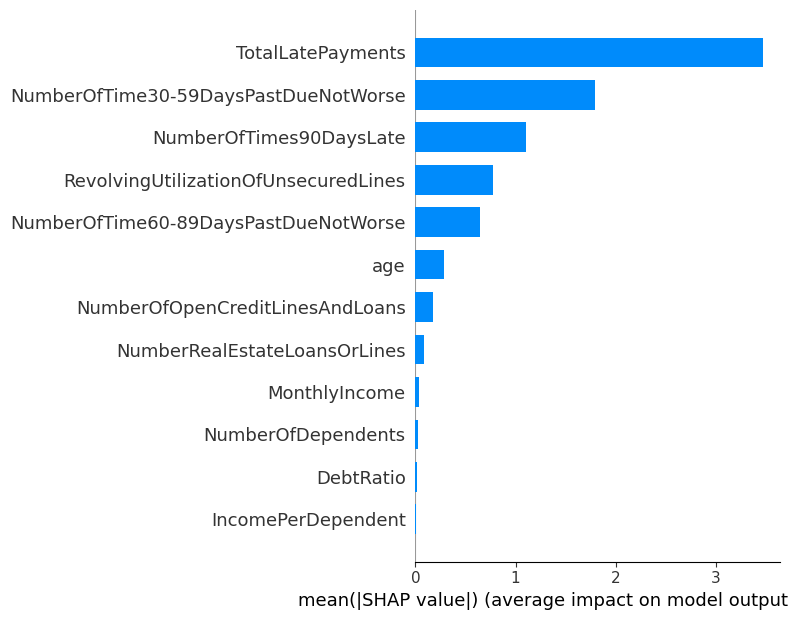

✅ SHAP complete!


In [62]:
# ============================================
# Cell 49 — SHAP Explainability
# ============================================

import shap  # imports SHAP library

# Step 1 — Take a small sample for speed
X_sample = pd.DataFrame(
    X_test_scaled[:500],   # takes first 500 rows from scaled test data
    columns=X.columns      # puts column names back — SHAP needs them
)

# Step 2 — Create SHAP explainer for Logistic Regression
explainer = shap.LinearExplainer(
    lr_model,              # our trained Logistic Regression model
    X_sample               # the sample data it will explain
)

# Step 3 — Calculate SHAP values
shap_values = explainer.shap_values(X_sample)  # calculates how much each feature contributed to each prediction

# Step 4 — Summary Plot
print("Generating SHAP Summary Plot...")
shap.summary_plot(
    shap_values,           # the calculated SHAP values
    X_sample,              # the sample data with column names
    plot_type="bar",       # bar chart — easiest to read for beginners
    max_display=12         # show all 12 features
)

print("✅ SHAP complete!")

Generating SHAP Dot Plot...


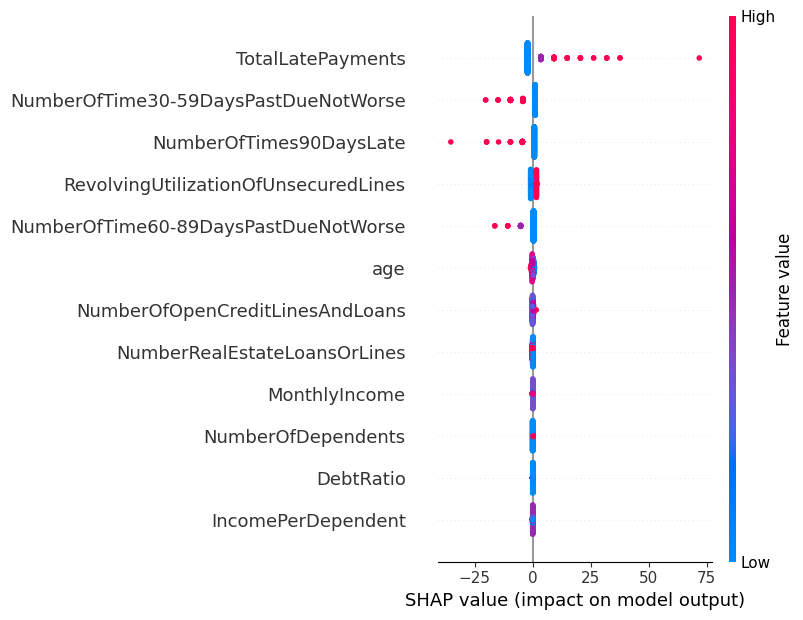

✅ SHAP Dot Plot complete!


In [63]:
# ============================================
# Cell 50 — SHAP Dot Plot
# ============================================

print("Generating SHAP Dot Plot...")

shap.summary_plot(
    shap_values,     # same SHAP values calculated in Cell 49
    X_sample,        # same sample data with column names
    plot_type="dot", # dot plot — shows direction AND magnitude
    max_display=12   # show all 12 features
)

print("✅ SHAP Dot Plot complete!")